C:\Users\Computação\AppData\Local\Temp\ipykernel_10364\213708898.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


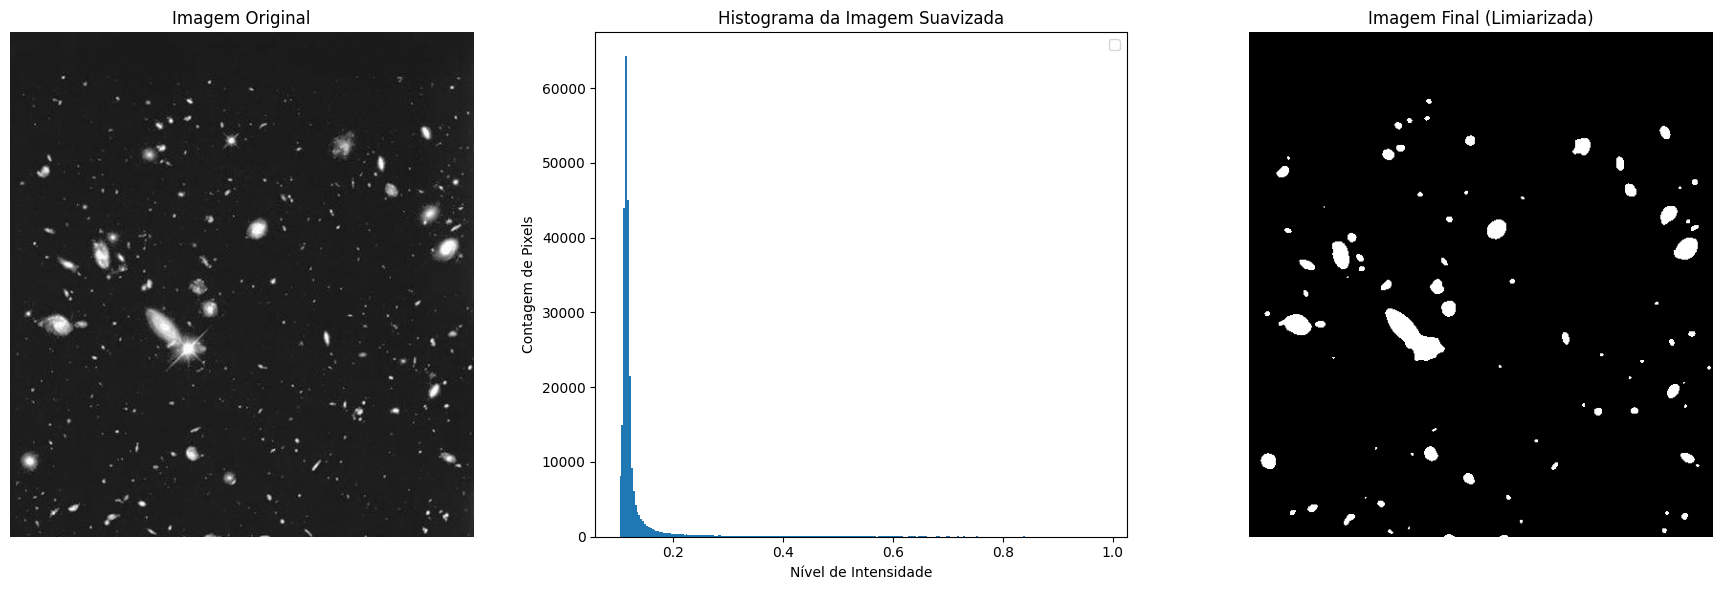

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
from skimage import io, color, util, filters

image_path = './images/FIG033_2.TIF'

try:
    image = io.imread(image_path)
    # Converte a imagem para escala de cinza se ela não estiver
    if image.ndim > 2:
        grayscale_img = color.rgb2gray(image)
    else:
        grayscale_img = image
except FileNotFoundError as e:
    print(e)
    # Finaliza a execução se o arquivo não for encontrado
    exit()

# Gaussian Blur
img_suavizada = filters.gaussian(grayscale_img, sigma=2.0)

# Limiarização
threshold = filters.threshold_otsu(img_suavizada)
binary_img = img_suavizada > threshold

# Imagem original, o histograma da imagem suavizada e a imagem final
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Imagem Original
axes[0].imshow(grayscale_img, cmap='gray')
axes[0].set_title('Imagem Original')
axes[0].axis('off')

# Histograma da Imagem Suavizada
axes[1].hist(img_suavizada.ravel(), bins=256)
axes[1].set_title('Histograma da Imagem Suavizada')
axes[1].set_xlabel('Nível de Intensidade')
axes[1].set_ylabel('Contagem de Pixels')
axes[1].legend()

# Imagem Final Limiarizada
axes[2].imshow(binary_img, cmap='gray')
axes[2].set_title('Imagem Final (Limiarizada)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

io.imsave('filtro-media_limiarizacao.png', util.img_as_ubyte(binary_img))